

#### Dataset Overview:
- The `guest_data_with_reviews.xlsx` dataset contains customer feedback from a hospitality business.
- Key columns include:
  - `How likely are you to recommend us to a friend or colleague?` for Net Promoter Score (NPS) calculations.
  - `Review` for textual feedback, useful for sentiment analysis and topic modeling.

#### Key Concepts:
1. **Net Promoter Score (NPS):** Measures customer loyalty. Scores:
   - 9–10: Promoters
   - 7–8: Passives
   - 0–6: Detractors
   - Formula: NPS = percentage of promoters - percentage of detractors

2. **Sentiment Analysis:** Identifies the emotional tone (positive, negative, or neutral) in reviews using pre-trained AI models.

3. **Topic Modeling:** Uses embeddings to identify recurring themes in text data.

---



### **Workbook Activities**

#### 1. Exploratory Data Analysis (EDA)


In [2]:
# Import plotly and pandas
import pandas as pd
import plotly.express as px

In [2]:
# Read in the dataset "guest_data_with_reviews.xlsx" and show the first five rows

In [3]:
# Read in the dataset "guest_data_with_reviews.xlsx" and show the first five rows
df = pd.read_excel("guest_data_with_reviews.xlsx")
df.head()

,ID,Start time,Completion time,Email,Name,Full Name,Gender,Date of Birth,Checkout Date,Purpose of the visit,How did you discover us?,Rate your overall experience in our hotel,How likely are you to recommend us to a friend or colleague?,Staff attitude,Check-in Process,Room service,Room cleanliness,Food quality,Variety of food,Broadband & TV,Gym,Review
0,1,NaN,NaN,NaN,NaN,Guest 00001,Male,1993-10-02,2022-04-07,Business,Organization,3,9,Good,Good,Very good,Poor,Very good,Average,Excellent,Excellent,it was an okay experience overall. the room wa...
1,3,NaN,NaN,NaN,NaN,Guest 00003,Male,1981-10-03,2020-01-16,Vacation,News paper,4,4,Poor,Good,Very good,Average,Poor,Poor,Good,Very good,the stay was memorable thanks to the poor staf...
2,4,NaN,NaN,NaN,NaN,Guest 00004,Male,2004-03-31,2022-05-14,Vacation,Search engine,5,6,Good,Very good,Good,Poor,Average,Poor,Poor,Excellent,while the staff were good and did their best t...
3,5,NaN,NaN,NaN,NaN,Guest 00005,Male,1961-08-08,2022-06-24,Business,hotel booking sites,5,5,Excellent,Excellent,Very good,Average,Good,Average,Excellent,Good,the hotel experience was average at best. the ...
4,8,NaN,NaN,NaN,NaN,Guest 00008,Male,1981-11-27,2020-02-01,Business,Organization,1,7,Good,Excellent,Good,Average,Excellent,Very good,Excellent,Very good,"not my favorite stay, but the good staff helpe..."


In [4]:
# What's the total length of the dataset?

In [4]:
# Calculate the total length of the dataset
total_length = len(df)
total_length

1108

In [7]:
# How would you identify missing values in this dataset?

In [5]:
# Identify missing values in the dataset
missing_values = df.isnull().sum()
missing_values

ID                                                                 0
Start time                                                      1108
Completion time                                                 1108
Email                                                           1108
Name                                                            1108
Full Name                                                          0
Gender                                                             0
Date of Birth                                                      0
Checkout Date                                                      0
Purpose of the visit                                               0
How did you discover us?                                           0
Rate your overall experience in our hotel                          0
How likely are you to recommend us to a friend or colleague?       0
Staff attitude                                                     0
Check-in Process                  

In [9]:
# How would you remove the missing values in this dataset?

In [10]:
# Remove the missing values in the dataset
df_cleaned = df.dropna()
df_cleaned

,ID,Start time,Completion time,Email,Name,Full Name,Gender,Date of Birth,Checkout Date,Purpose of the visit,How did you discover us?,Rate your overall experience in our hotel,How likely are you to recommend us to a friend or colleague?,Staff attitude,Check-in Process,Room service,Room cleanliness,Food quality,Variety of food,Broadband & TV,Gym,Review


* *Note that this has eliminated all rows from the dataset, so we need to go back with a more specific prompt.

In [11]:
# Remove columns where all values are missing
df_cleaned = df.dropna(axis=1, how='all')

# Remove rows where any values are missing
df_cleaned = df_cleaned.dropna()

# Show the first five rows of the resulting dataset
df_cleaned.head()

,ID,Full Name,Gender,Date of Birth,Checkout Date,Purpose of the visit,How did you discover us?,Rate your overall experience in our hotel,How likely are you to recommend us to a friend or colleague?,Staff attitude,Check-in Process,Room service,Room cleanliness,Food quality,Variety of food,Broadband & TV,Gym,Review
0,1,Guest 00001,Male,1993-10-02,2022-04-07,Business,Organization,3,9,Good,Good,Very good,Poor,Very good,Average,Excellent,Excellent,it was an okay experience overall. the room wa...
1,3,Guest 00003,Male,1981-10-03,2020-01-16,Vacation,News paper,4,4,Poor,Good,Very good,Average,Poor,Poor,Good,Very good,the stay was memorable thanks to the poor staf...
2,4,Guest 00004,Male,2004-03-31,2022-05-14,Vacation,Search engine,5,6,Good,Very good,Good,Poor,Average,Poor,Poor,Excellent,while the staff were good and did their best t...
3,5,Guest 00005,Male,1961-08-08,2022-06-24,Business,hotel booking sites,5,5,Excellent,Excellent,Very good,Average,Good,Average,Excellent,Good,the hotel experience was average at best. the ...
4,8,Guest 00008,Male,1981-11-27,2020-02-01,Business,Organization,1,7,Good,Excellent,Good,Average,Excellent,Very good,Excellent,Very good,"not my favorite stay, but the good staff helpe..."


In [12]:
# We're interested in the recommendation scores. What is their distribution? 

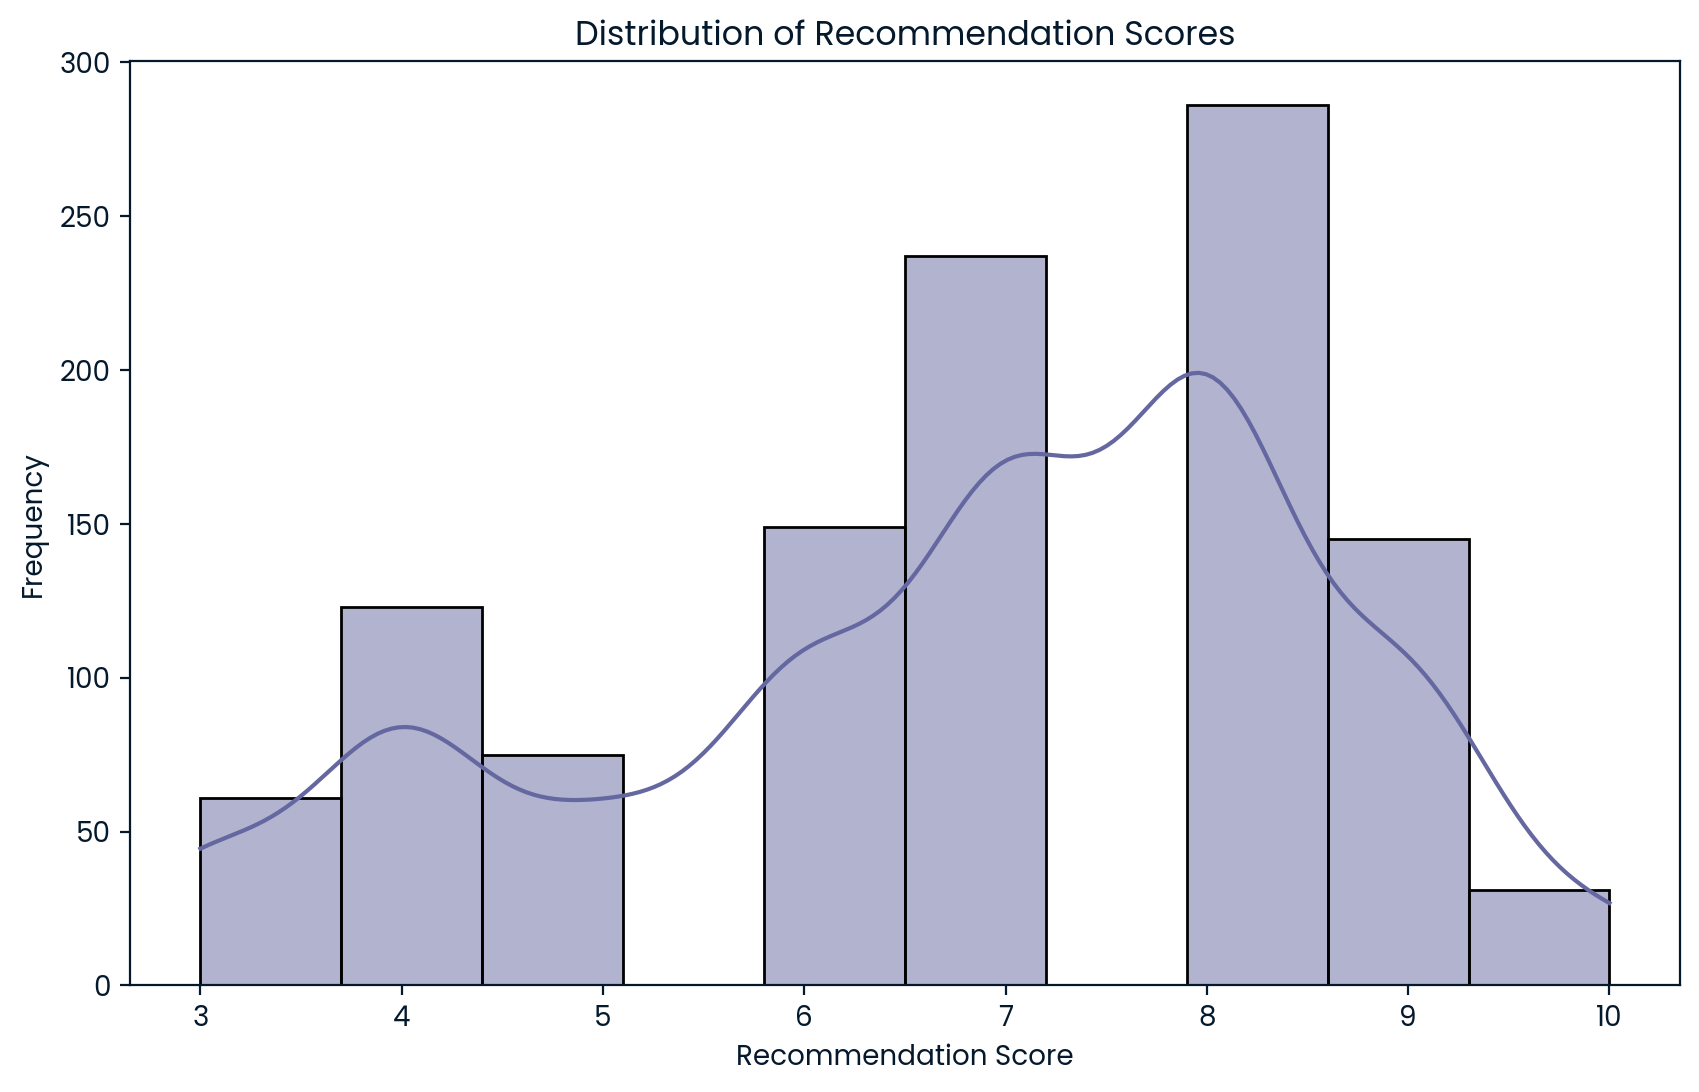

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of recommendation scores
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned["How likely are you to recommend us to a friend or colleague?"], bins=10, kde=True)
plt.title("Distribution of Recommendation Scores")
plt.xlabel("Recommendation Score")
plt.ylabel("Frequency")
plt.show()

* *Note that the AI used seaborn, but we want to use plotly. We need to ask for the specific library on the prompt.

In [14]:
import plotly.express as px

# Plot the distribution of recommendation scores using plotly
fig = px.histogram(df_cleaned, 
                   x="How likely are you to recommend us to a friend or colleague?", 
                   nbins=10, 
                   title="Distribution of Recommendation Scores",
                   labels={"How likely are you to recommend us to a friend or colleague?": "Recommendation Score"},
                   marginal="box")

fig.update_layout(
    xaxis_title="Recommendation Score",
    yaxis_title="Frequency"
)

fig.show()

#### 2. Calculate NPS

In [15]:
# Classify scores as promoters (9-10), passives (7-8), and detractors (0-6)

In [16]:
# Classify scores as promoters (9-10), passives (7-8), and detractors (0-6)
def classify_nps(score):
    if score >= 9:
        return 'Promoter'
    elif score >= 7:
        return 'Passive'
    else:
        return 'Detractor'

# Apply the classification to the dataframe
df_cleaned['NPS Category'] = df_cleaned["How likely are you to recommend us to a friend or colleague?"].apply(classify_nps)

# Display the first few rows to verify the new column
df_cleaned.head()

,ID,Full Name,Gender,Date of Birth,Checkout Date,Purpose of the visit,How did you discover us?,Rate your overall experience in our hotel,How likely are you to recommend us to a friend or colleague?,Staff attitude,Check-in Process,Room service,Room cleanliness,Food quality,Variety of food,Broadband & TV,Gym,Review,NPS Category
0,1,Guest 00001,Male,1993-10-02,2022-04-07,Business,Organization,3,9,Good,Good,Very good,Poor,Very good,Average,Excellent,Excellent,it was an okay experience overall. the room wa...,Promoter
1,3,Guest 00003,Male,1981-10-03,2020-01-16,Vacation,News paper,4,4,Poor,Good,Very good,Average,Poor,Poor,Good,Very good,the stay was memorable thanks to the poor staf...,Detractor
2,4,Guest 00004,Male,2004-03-31,2022-05-14,Vacation,Search engine,5,6,Good,Very good,Good,Poor,Average,Poor,Poor,Excellent,while the staff were good and did their best t...,Detractor
3,5,Guest 00005,Male,1961-08-08,2022-06-24,Business,hotel booking sites,5,5,Excellent,Excellent,Very good,Average,Good,Average,Excellent,Good,the hotel experience was average at best. the ...,Detractor
4,8,Guest 00008,Male,1981-11-27,2020-02-01,Business,Organization,1,7,Good,Excellent,Good,Average,Excellent,Very good,Excellent,Very good,"not my favorite stay, but the good staff helpe...",Passive


In [ ]:
# What proportion of customers are promoters, passives, and detractors?

In [17]:
# Calculate the proportion of customers in each NPS category
nps_proportions = df_cleaned['NPS Category'].value_counts(normalize=True) * 100

# Display the proportions
nps_proportions

NPS Category
Passive      47.244806
Detractor    36.856369
Promoter     15.898826
Name: proportion, dtype: float64

In [18]:
# Calculate the overall NPS and interpret its meaning

In [19]:
# Calculate the overall NPS and interpret its meaning

# Calculate the number of promoters, passives, and detractors
promoters = df_cleaned[df_cleaned['NPS Category'] == 'Promoter'].shape[0]
passives = df_cleaned[df_cleaned['NPS Category'] == 'Passive'].shape[0]
detractors = df_cleaned[df_cleaned['NPS Category'] == 'Detractor'].shape[0]

# Calculate the total number of responses
total_responses = df_cleaned.shape[0]

# Calculate the NPS score
nps_score = ((promoters - detractors) / total_responses) * 100

# Display the NPS score
nps_score

# Interpretation:
# NPS can range from -100 to 100.
# A positive NPS (>0) is generally considered good, with higher scores indicating better customer satisfaction and loyalty.
# An NPS of 50 or more is considered excellent.
# An NPS below 0 indicates that there are more detractors than promoters, which is a sign of customer dissatisfaction.

-20.957542908762424

In [20]:
# What does the NPS value indicate about customer loyalty?

In [21]:
# Interpretation of the NPS value in terms of customer loyalty

# Interpretation:
# NPS can range from -100 to 100.
# A positive NPS (>0) is generally considered good, with higher scores indicating better customer satisfaction and loyalty.
# An NPS of 50 or more is considered excellent.
# An NPS below 0 indicates that there are more detractors than promoters, which is a sign of customer dissatisfaction.

if nps_score > 50:
    loyalty_interpretation = "Excellent customer loyalty"
elif nps_score > 0:
    loyalty_interpretation = "Good customer loyalty"
else:
    loyalty_interpretation = "Poor customer loyalty"

loyalty_interpretation

'Poor customer loyalty'

#### 3. Sentiment Analysis 

In [22]:
# Analyze sentiments in the reviews using a pre-trained model

In [23]:
!pip install tf-keras

Defaulting to user installation because normal site-packages is not writeable


In [24]:
from transformers import pipeline

# Load pre-trained sentiment-analysis model
sentiment_analyzer = pipeline('sentiment-analysis')

# Analyze sentiments in the reviews
df_cleaned['Sentiment'] = df_cleaned['Review'].apply(lambda review: sentiment_analyzer(review)[0]['label'])

# Display the dataframe with the new Sentiment column
df_cleaned.head()

2025-01-14 18:24:41.788004: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736879081.804680    1801 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736879081.809320    1801 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-14 18:24:41.825985: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://

,ID,Full Name,Gender,Date of Birth,Checkout Date,Purpose of the visit,How did you discover us?,Rate your overall experience in our hotel,How likely are you to recommend us to a friend or colleague?,Staff attitude,Check-in Process,Room service,Room cleanliness,Food quality,Variety of food,Broadband & TV,Gym,Review,NPS Category,Sentiment
0,1,Guest 00001,Male,1993-10-02,2022-04-07,Business,Organization,3,9,Good,Good,Very good,Poor,Very good,Average,Excellent,Excellent,it was an okay experience overall. the room wa...,Promoter,POSITIVE
1,3,Guest 00003,Male,1981-10-03,2020-01-16,Vacation,News paper,4,4,Poor,Good,Very good,Average,Poor,Poor,Good,Very good,the stay was memorable thanks to the poor staf...,Detractor,NEGATIVE
2,4,Guest 00004,Male,2004-03-31,2022-05-14,Vacation,Search engine,5,6,Good,Very good,Good,Poor,Average,Poor,Poor,Excellent,while the staff were good and did their best t...,Detractor,NEGATIVE
3,5,Guest 00005,Male,1961-08-08,2022-06-24,Business,hotel booking sites,5,5,Excellent,Excellent,Very good,Average,Good,Average,Excellent,Good,the hotel experience was average at best. the ...,Detractor,NEGATIVE
4,8,Guest 00008,Male,1981-11-27,2020-02-01,Business,Organization,1,7,Good,Excellent,Good,Average,Excellent,Very good,Excellent,Very good,"not my favorite stay, but the good staff helpe...",Passive,POSITIVE


* *Note that we had to run the cell above twice, as the first time we had an error asking to run `pip install tf-keras`

In [25]:
# Visualize sentiment distribution across the dataset

In [26]:
import plotly.express as px

# Create a bar plot for sentiment distribution
df_sentiment = df_cleaned['Sentiment'].value_counts().reset_index()
df_sentiment.columns = ['Sentiment', 'Count']

fig = px.bar(df_sentiment, 
             x='Sentiment', 
             y='Count', 
             labels={'Sentiment': 'Sentiment', 'Count': 'Count'},
             title='Sentiment Distribution')

# Show the plot
fig.show()

In [27]:
# How would you interpret the sentiment distribution?

In [28]:
# Interpretation of the sentiment distribution

# Calculate the percentage of each sentiment
df_sentiment['Percentage'] = (df_sentiment['Count'] / df_sentiment['Count'].sum()) * 100

# Display the sentiment distribution with percentages
df_sentiment

,Sentiment,Count,Percentage
0,NEGATIVE,829,74.887082
1,POSITIVE,278,25.112918


#### 4. Topic Modeling

In [ ]:
# What are some common keywords in the reviews?

In [29]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Extract the reviews from the dataframe
reviews = df_cleaned['Review'].dropna().tolist()

# Initialize the CountVectorizer
vectorizer = CountVectorizer(stop_words='english', max_features=20)

# Fit and transform the reviews
X = vectorizer.fit_transform(reviews)

# Get the feature names (keywords)
keywords = vectorizer.get_feature_names_out()

# Sum up the counts of each keyword
keyword_counts = X.toarray().sum(axis=0)

# Create a dataframe for the keywords and their counts
df_keywords = pd.DataFrame({'Keyword': keywords, 'Count': keyword_counts})

# Sort the dataframe by count in descending order
df_keywords = df_keywords.sort_values(by='Count', ascending=False)

# Display the dataframe
df_keywords

,Keyword,Count
14,room,1107
7,food,1002
8,good,996
15,staff,896
16,stay,456
6,experience,454
2,cleanliness,403
1,best,314
4,excellent,307
18,wasn,306


In [ ]:
# Extract key topics from the reviews using embeddings

In [30]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)

# Fit and transform the reviews
tfidf_matrix = tfidf_vectorizer.fit_transform(reviews)

# Initialize the LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=42)

# Fit the LDA model to the tfidf matrix
lda.fit(tfidf_matrix)

# Get the topics and their top words
def display_topics(model, feature_names, no_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx+1}"] = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
    return topics

# Display the topics
no_top_words = 10
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
topics = display_topics(lda, tfidf_feature_names, no_top_words)
topics

{'Topic 1': ['left',
  'hoped',
  'nice',
  'ups',
  'quite',
  'downs',
  'touch',
  'desired',
  'demeanor',
  'fell'],
 'Topic 2': ['approach',
  'make',
  'okay',
  'use',
  'bit',
  'work',
  'tried',
  'overall',
  'good',
  'experience'],
 'Topic 3': ['dragged',
  'nature',
  'stood',
  'subpar',
  'lackluster',
  'overall',
  'cleanliness',
  'experience',
  'staff',
  'food'],
 'Topic 4': ['best',
  'helped',
  'favorite',
  'upgrades',
  'need',
  'consider',
  'returning',
  'significant',
  'stay',
  'wasn'],
 'Topic 5': ['didn',
  'quality',
  'team',
  'cleanliness',
  'thanks',
  'memorable',
  'match',
  'unfortunately',
  'leave',
  'impression']}

In [ ]:
# Visualize results as a word cloud

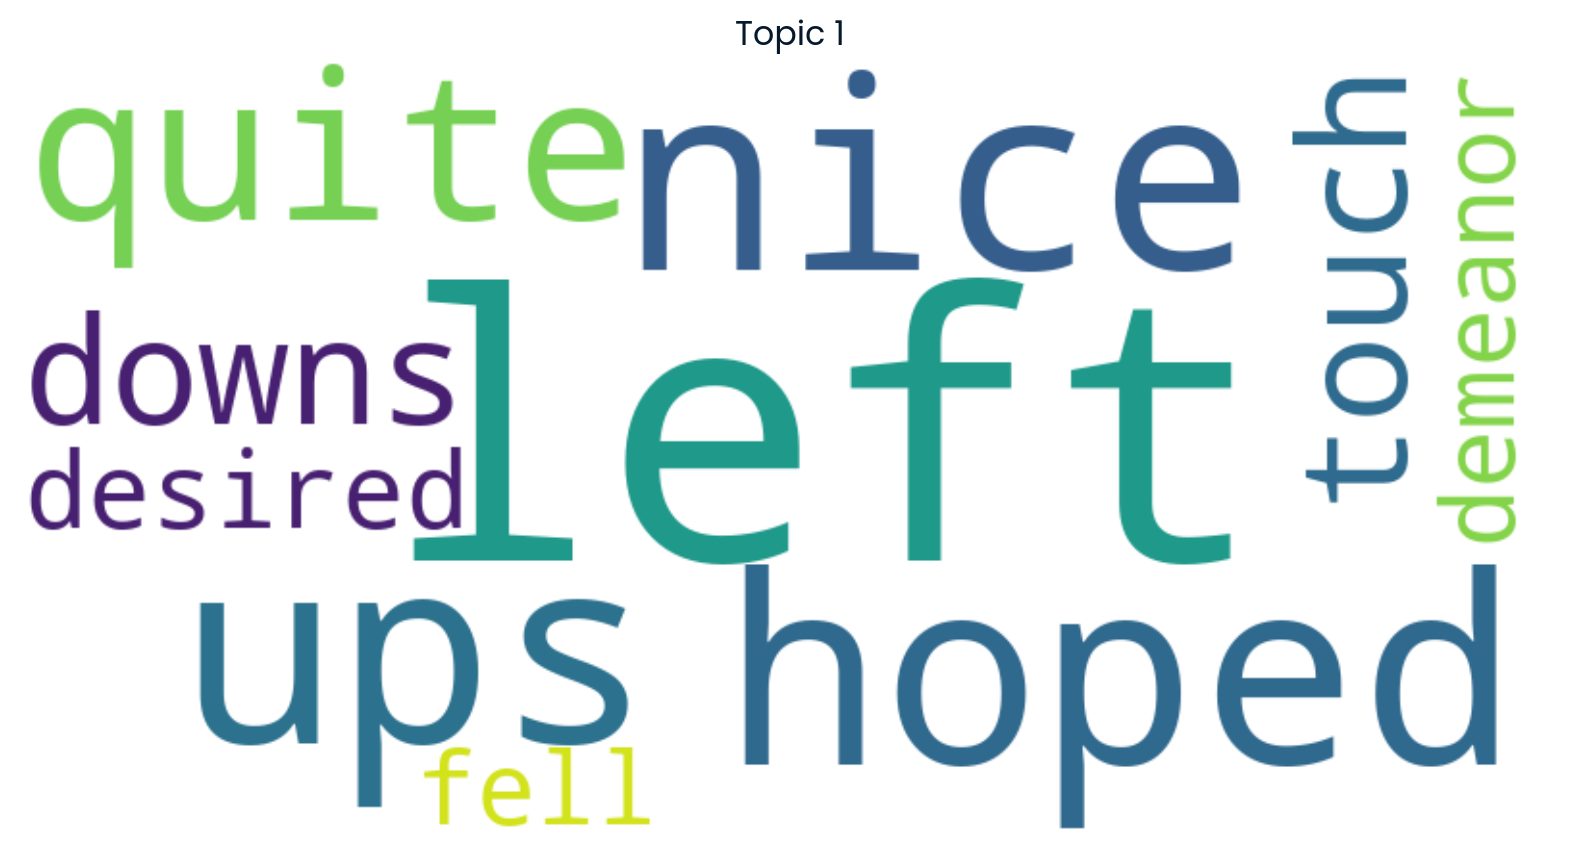

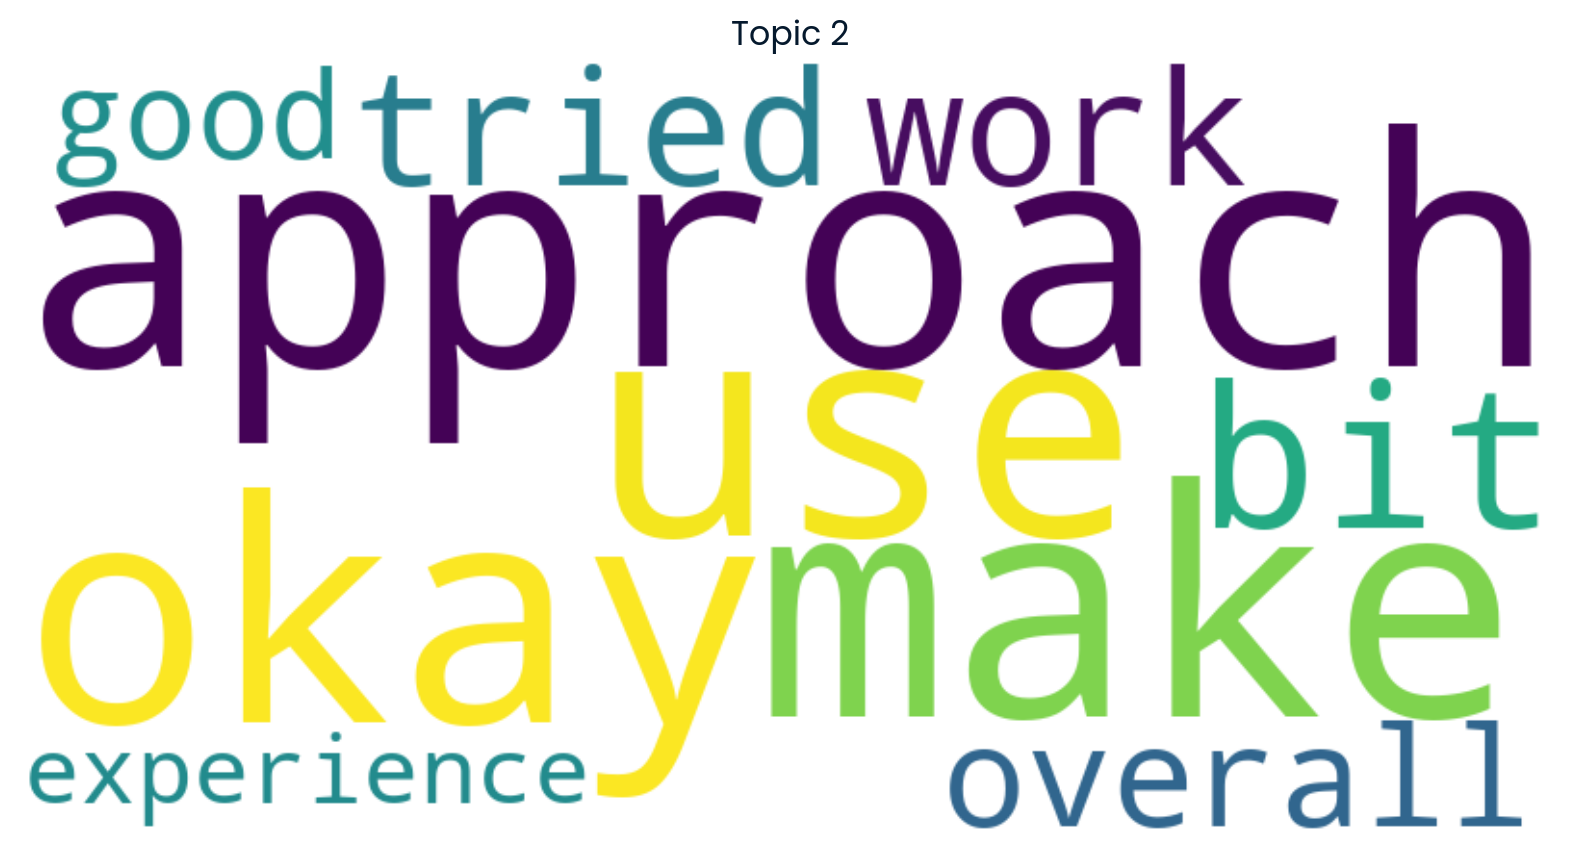

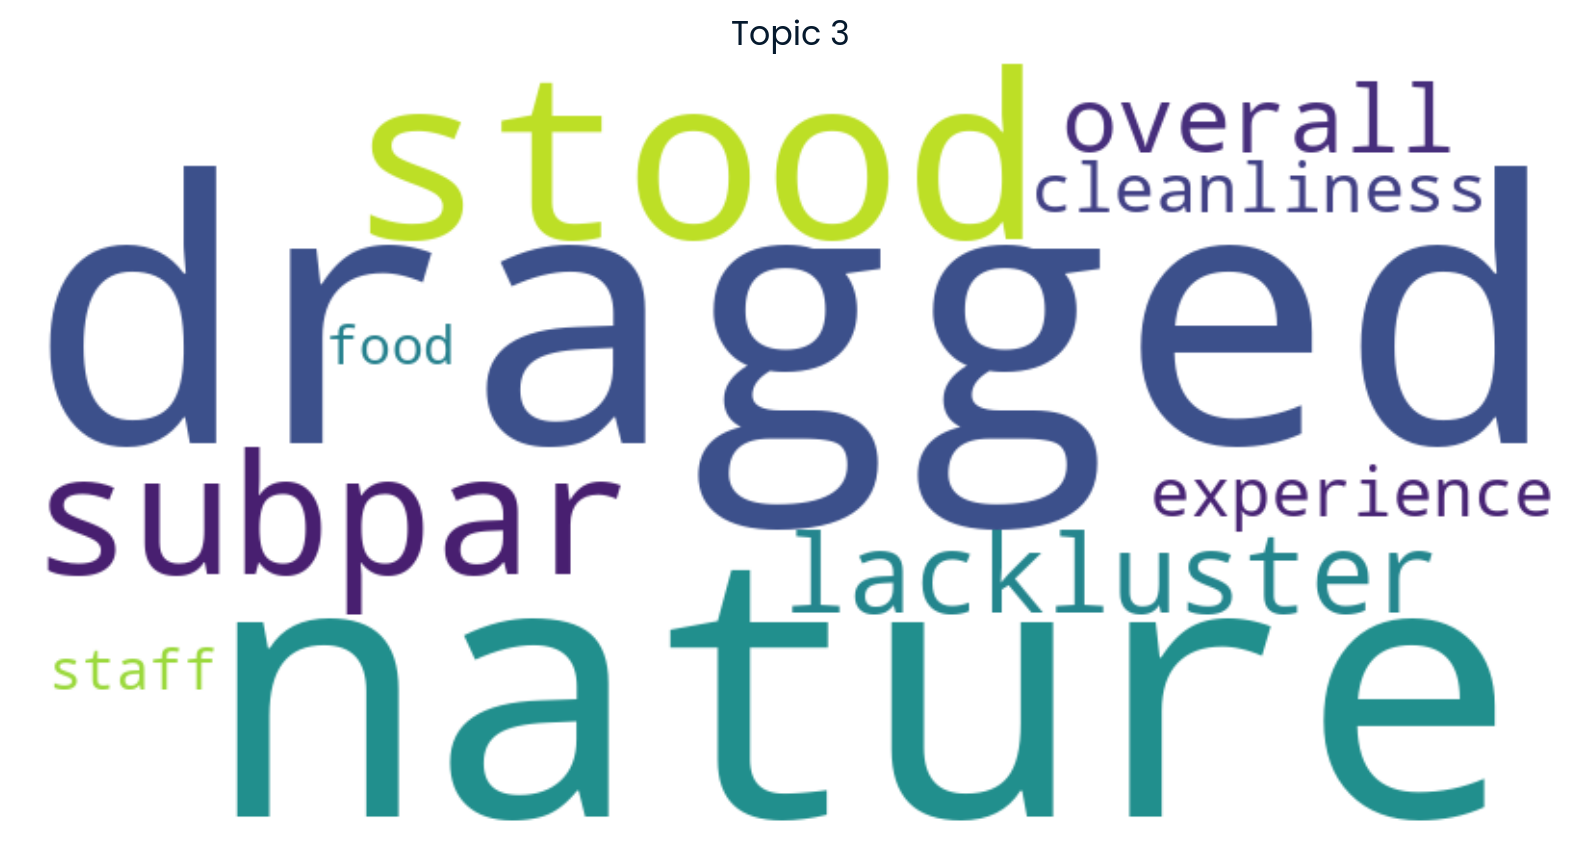

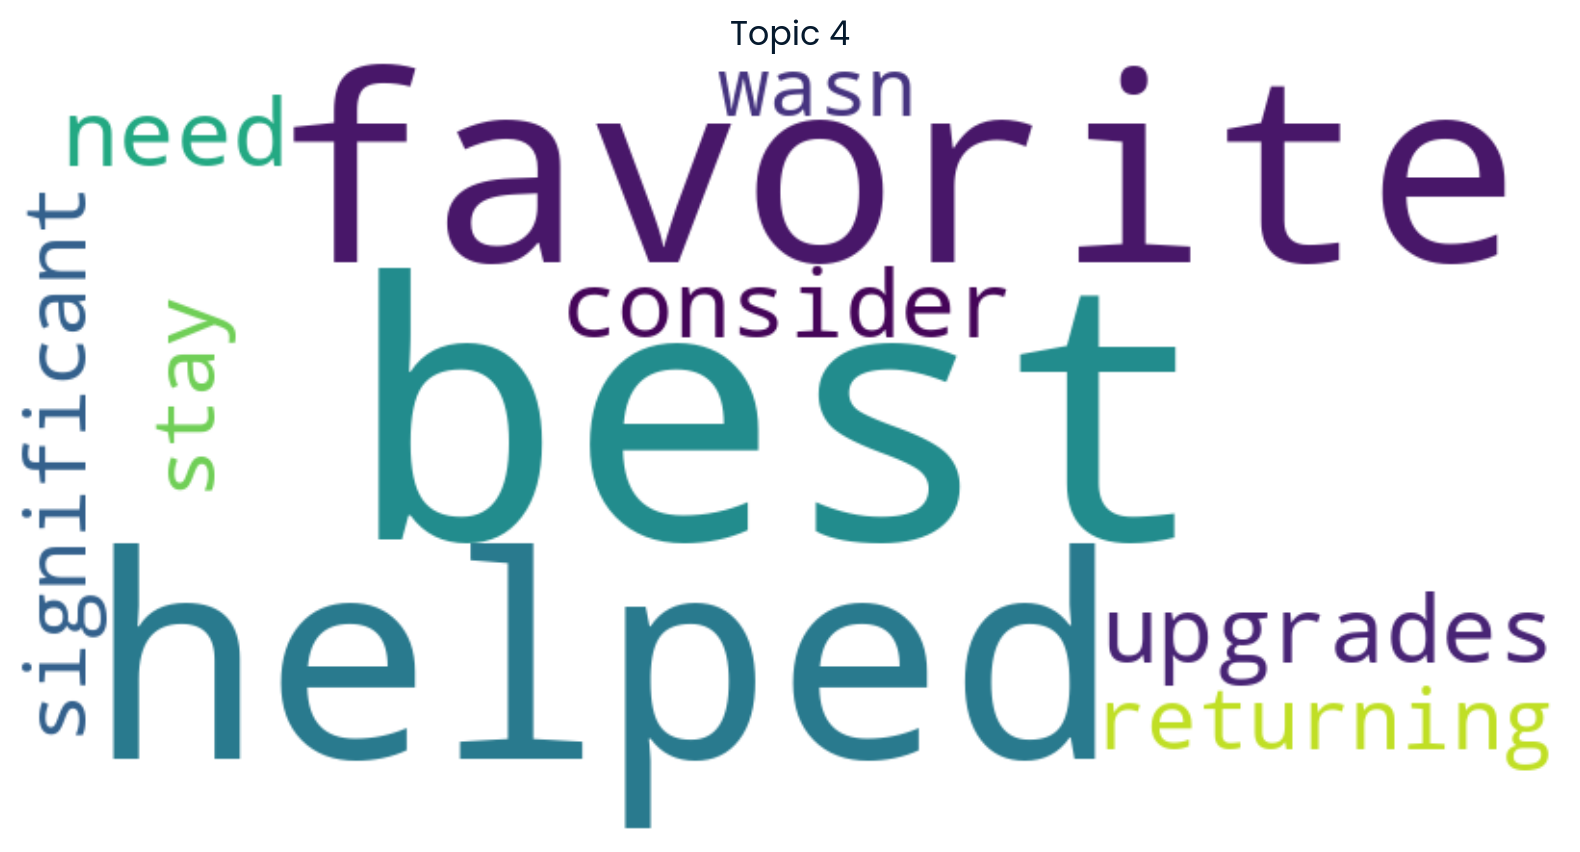

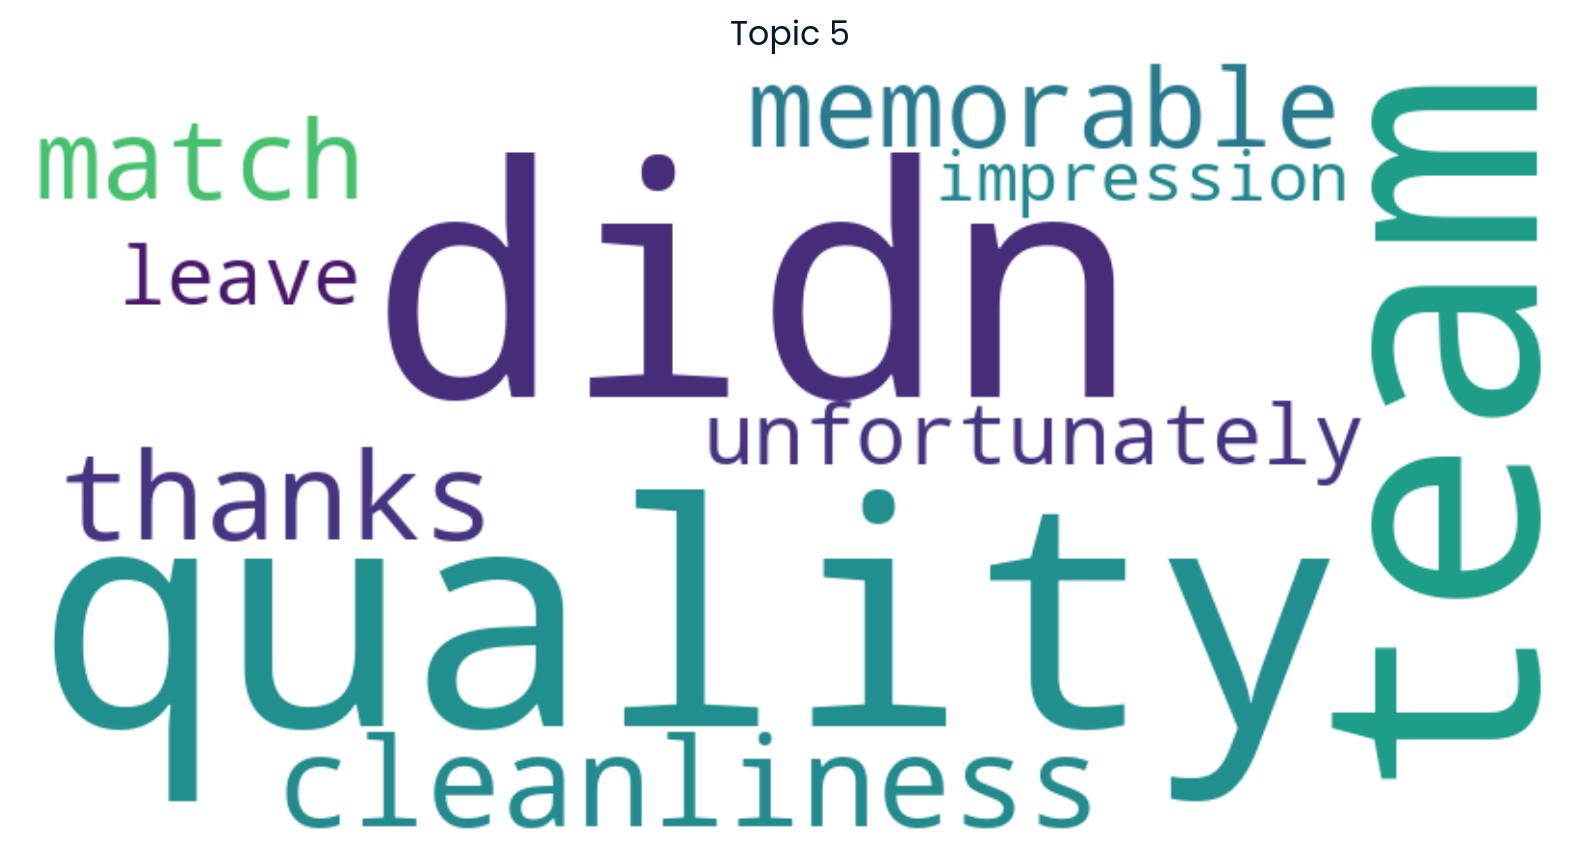

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to plot word cloud for each topic
def plot_word_cloud(lda_model, feature_names, num_top_words):
    for topic_idx, topic in enumerate(lda_model.components_):
        word_freq = {feature_names[i]: topic[i] for i in topic.argsort()[:-num_top_words - 1:-1]}
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
        
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Topic {topic_idx+1}')
        plt.show()

# Plot word clouds for each topic
plot_word_cloud(lda, tfidf_feature_names, no_top_words)